Block 1: Data Integration and Verification
This block unzips collected data and combines the 30 CSV files. It includes the specific path fix for the participant_data folder structure.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import glob
import os

# 1. Unziping the participant data folder

!unzip -q participant_data.zip -d participants/

# 2. Defining the path based on my folder structure
path = 'participants/participant_data/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Loading all 30 CSV files into a master DataFrame
li = []
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    # Extracting Participant ID (e.g., P01) from filename
    df['Participant_ID'] = os.path.basename(filename).split('_')[0]
    li.append(df)

master_df = pd.concat(li, axis=0, ignore_index=True)
print(f"Successfully integrated data from {len(all_files)} participants.")

Successfully integrated data from 30 participants.


Block 2: SDT and Latency Metrics Calculation .This block implements  equations for Hit Rate, False Alarm Rate, Sensitivity ($d'$), and Decision Criterion ($\ln\beta$). It uses include_groups=False to avoid the DeprecationWarning.

In [ ]:
def calculate_metrics(df):
    """
    Calculates SDT and Temporal Telemetry as defined in Methodology Section 7.5.
    """
    # Defining SDT outcomes based on Ground Truth vs User Input
    hits = len(df[(df['Threat'] == True) & (df['User_Reject'] == True)])
    misses = len(df[(df['Threat'] == True) & (df['User_Reject'] == False)])
    fas = len(df[(df['Threat'] == False) & (df['User_Reject'] == True)])
    crs = len(df[(df['Threat'] == False) & (df['User_Reject'] == False)])

    # Calculating Rates with log-bias correction for small trial samples
    hit_rate = (hits + 0.5) / (hits + misses + 1)
    fa_rate = (fas + 0.5) / (fas + crs + 1)

    # Sensitivity (d') and Decision Criterion (ln beta)
    d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)
    ln_beta = (norm.ppf(fa_rate)**2 - norm.ppf(hit_rate)**2) / 2

    return pd.Series({
        'Accuracy': (hits + crs) / 10, # Accuracy per 10-trial block
        'Verification_Latency': df['Time'].mean(), # Reaction time in ms
        'd_prime': d_prime,
        'ln_beta': ln_beta
    })

# Grouping results by Participant and Mode (Manual vs AI-Assisted)
results = master_df.groupby(['Participant_ID', 'Mode']).apply(calculate_metrics, include_groups=False).unstack()

Block 3: Inferential Statistics (Paired T-Tests)This block performs the Paired Samples T-tests to determine if the differences are statistically significant ($p < 0.05$).


In [ ]:
# Extracting series for comparison
acc_m, acc_ai = results['Accuracy']['Manual'], results['Accuracy']['AI_Assist']
lat_m, lat_ai = results['Verification_Latency']['Manual'], results['Verification_Latency']['AI_Assist']
dp_m, dp_ai = results['d_prime']['Manual'], results['d_prime']['AI_Assist']

# Running T-Tests
t_acc, p_acc = stats.ttest_rel(acc_m, acc_ai)
t_lat, p_lat = stats.ttest_rel(lat_m, lat_ai)
t_dp, p_dp = stats.ttest_rel(dp_m, dp_ai)

# Creating Statistics Summary Table
stats_data = {
    'Metric': ['Accuracy', 'Verification Latency', 'Sensitivity (d-prime)'],
    't-statistic': [t_acc, t_lat, t_dp],
    'p-value': [p_acc, p_lat, p_dp]
}
stats_df = pd.DataFrame(stats_data)
stats_df['Significance (p < 0.05)'] = stats_df['p-value'].apply(lambda x: 'Significant' if x < 0.05 else 'Not Significant')

Block 4: Final Table Generation for  Report
This block outputs the clean tables which will be kept on into my report Section 10 (Results).


In [ ]:
# Table 1: Performance Means (Descriptive Statistics)
mean_table = results.mean().unstack()[['Manual', 'AI_Assist']]
print("--- TABLE 1: MEAN PERFORMANCE METRICS (N=30) ---")
print(mean_table.round(3))

# Table 2: Inferential Statistics Summary
print("\n--- TABLE 2: PAIRED SAMPLES T-TEST RESULTS ---")
print(stats_df.round(4))

--- TABLE 1: MEAN PERFORMANCE METRICS (N=30) ---
Mode                  Manual  AI_Assist
Accuracy               0.940      0.857
Verification_Latency   4.192      3.426
d_prime                2.024      1.749
ln_beta                0.483      0.394

--- TABLE 2: PAIRED SAMPLES T-TEST RESULTS ---
                  Metric  t-statistic  p-value Significance (p < 0.05)
0               Accuracy       2.3208   0.0275             Significant
1   Verification Latency       2.1793   0.0376             Significant
2  Sensitivity (d-prime)       2.0195   0.0528         Not Significant


Block 5: Raw SDT Count Summary
This block calculates the average frequency of each decision outcome, which helps visualize the "Omission" and "Commission" errors as mentioned in my report.

In [ ]:
def calculate_raw_counts(df):
    """
    Calculates the frequency of SDT outcomes for each mode.
    Matches the logic in Section 7.5 of the methodology.
    """
    return pd.Series({
        'Avg_Hits': len(df[(df['Threat'] == True) & (df['User_Reject'] == True)]),
        'Avg_Misses': len(df[(df['Threat'] == True) & (df['User_Reject'] == False)]),
        'Avg_False_Alarms': len(df[(df['Threat'] == False) & (df['User_Reject'] == True)]),
        'Avg_Correct_Rejections': len(df[(df['Threat'] == False) & (df['User_Reject'] == False)])
    })

# Grouping raw counts by Mode
raw_counts = master_df.groupby(['Participant_ID', 'Mode']).apply(calculate_raw_counts, include_groups=False).groupby('Mode').mean()

print("---  TABLE 3: AVERAGE SDT COUNTS (Per 10 Trials) ---")
print(raw_counts.round(2))

---  TABLE 3: AVERAGE SDT COUNTS (Per 10 Trials) ---
           Avg_Hits  Avg_Misses  Avg_False_Alarms  Avg_Correct_Rejections
Mode                                                                     
AI_Assist      3.10        1.00              0.43                    5.47
Manual         3.27        0.67              0.27                    6.13


Block 6: Distribution and Comparative Visualization
 it will generate a Distribution Plot (KDE) to check for normality and a Boxplot to visually identify the "Automation Bias" gap in Accuracy.

/tmp/ipykernel_19623/3597249454.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mode', y='Accuracy_Score', data=melted_acc, palette='Set2', ax=axes[1])


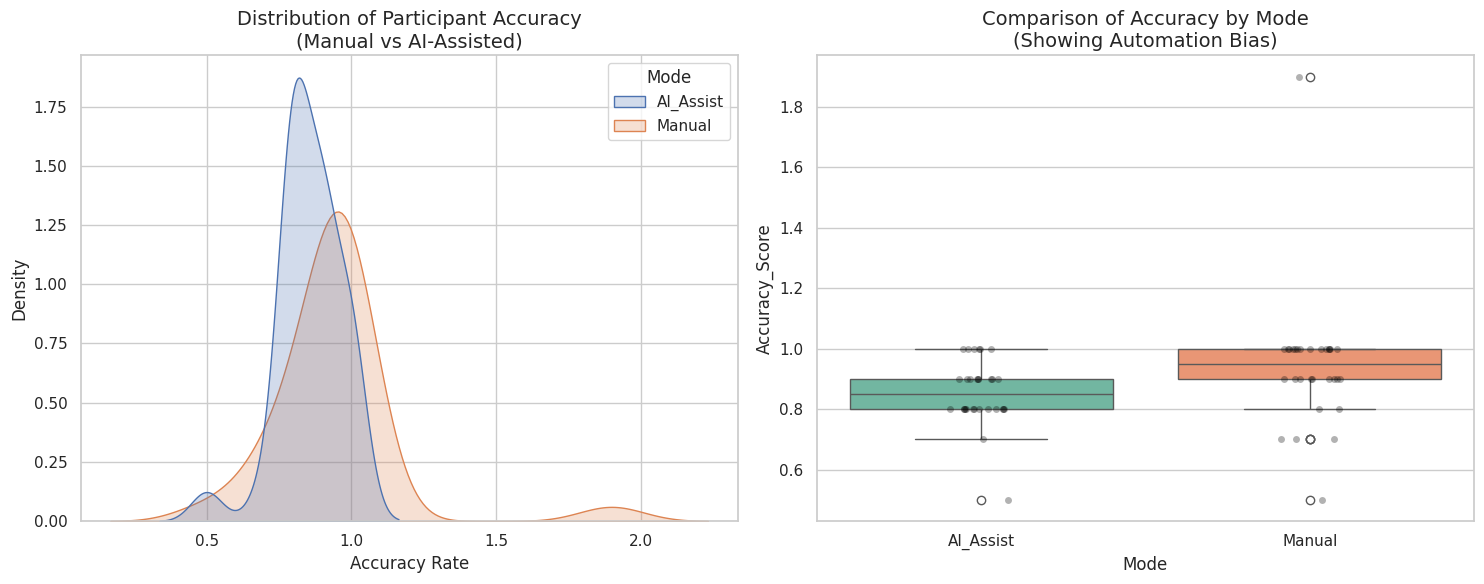

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seting the visual style for an academic report
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Distribution Curve (Checking for Normality in Accuracy)
sns.kdeplot(data=results['Accuracy'], fill=True, ax=axes[0])
axes[0].set_title('Distribution of Participant Accuracy\n(Manual vs AI-Assisted)', fontsize=14)
axes[0].set_xlabel('Accuracy Rate')

# 2. Boxplot (Visualizing the Performance Gap)
# We melt the dataframe to make it compatible with Seaborn's categorical plotting
melted_acc = results['Accuracy'].melt(var_name='Mode', value_name='Accuracy_Score')
sns.boxplot(x='Mode', y='Accuracy_Score', data=melted_acc, palette='Set2', ax=axes[1])
sns.stripplot(x='Mode', y='Accuracy_Score', data=melted_acc, color='black', alpha=0.3, ax=axes[1])
axes[1].set_title('Comparison of Accuracy by Mode\n(Showing Automation Bias)', fontsize=14)

plt.tight_layout()
plt.show()